Mounted at /content/drive
Device: cuda


/tmp/ipykernel_2175/864217696.py:402: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler    = GradScaler()


✅ Resumed from epoch 300, step 49868
Model parameters: 2.74M

=== Test Results ===
  Rain100L    PSNR=28.908  SSIM=0.9709
  Rain100H    PSNR=26.480  SSIM=0.9583
  Test1200    PSNR=31.845  SSIM=0.9865
  Test100     PSNR=24.394  SSIM=0.9592
  Test2800    PSNR=28.761  SSIM=0.9870

  Overall Avg  PSNR=28.078  SSIM=0.9724


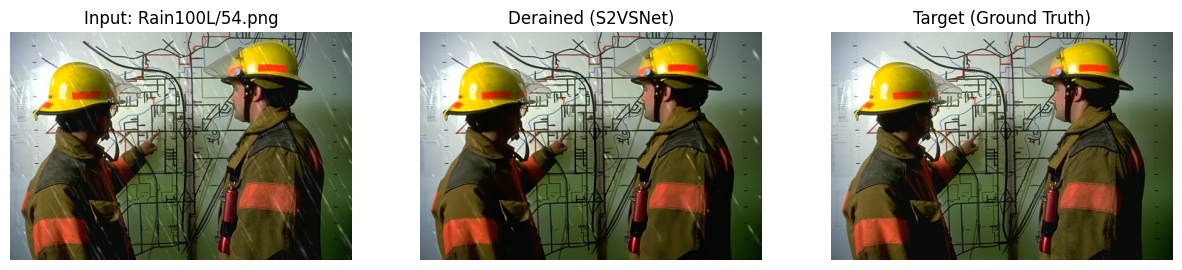

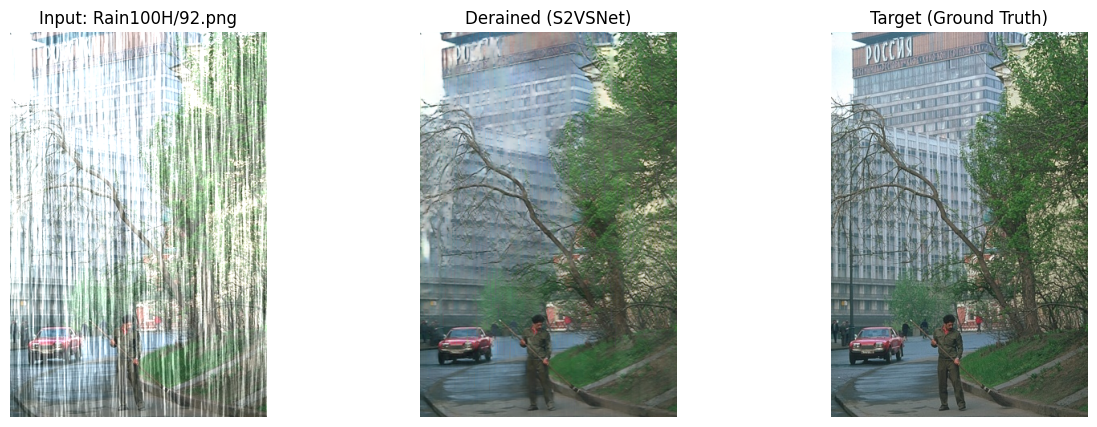

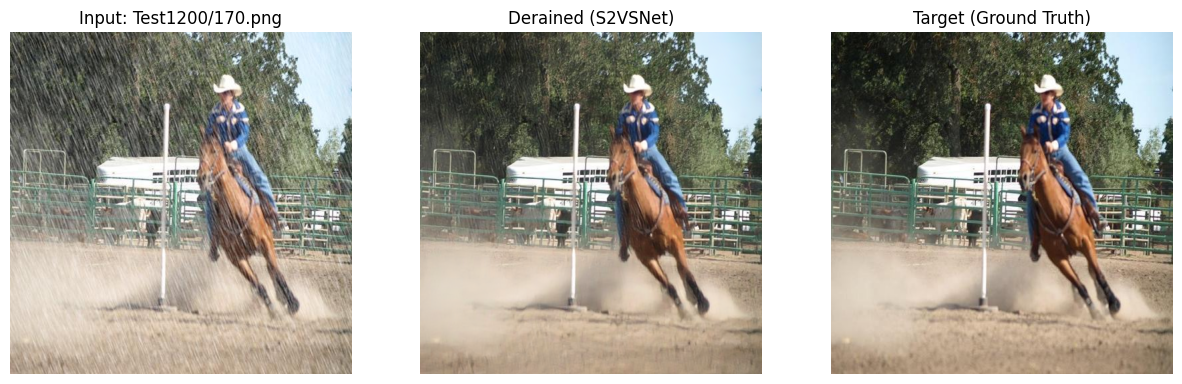

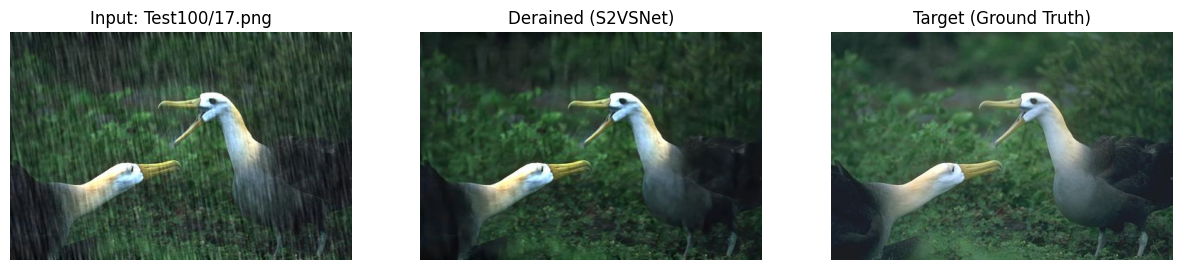

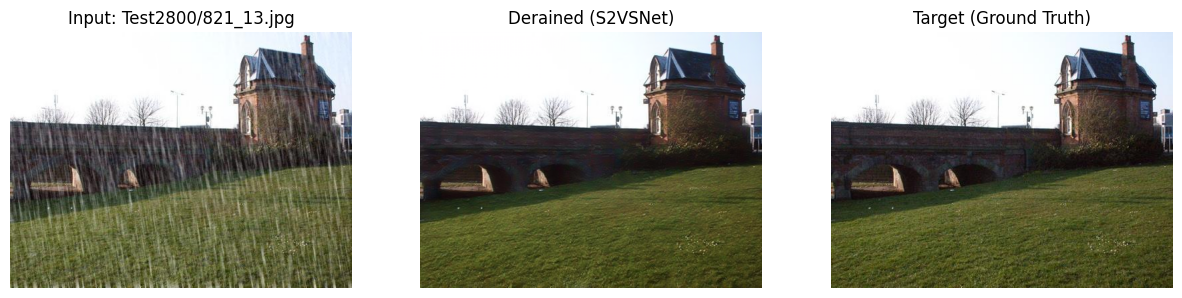

In [ ]:
# -*- coding: utf-8 -*-
"""
S2VSNet-inspired deraining for Computer Vision Project.
Image deraining is a important preprocessing step for outdoor CV systems.
Rain streaks degrade image visibility and the performance of downstream
tasks like object detection.
Key features:
  - Cascaded FFM (hierarchical, top-to-bottom)
  - NALM with SimpleGate + SCAM
  - Gradient clipping
  - Warmup + Cosine scheduler
  - Effective batch via gradient accumulation
  - More epochs with better resuming
"""

from google.colab import drive
drive.mount("/content/drive")

TRAIN_ROOT = "/content/drive/MyDrive/DATASET_SDP2025/RAIN/train"
TEST_ROOT  = "/content/drive/MyDrive/DATASET_SDP2025/RAIN/test"
CKPT_DIR   = "/content/drive/MyDrive/DATASET_SDP2025/checkpoints_v2"

import os, random, math
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms.functional as TF
from torch.cuda.amp import autocast, GradScaler

IMG_EXTS = (".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff", ".webp")


# ─────────────────────────────────────────
# Dataset
# ─────────────────────────────────────────
def list_images(folder):
    files = [f for f in os.listdir(folder) if f.lower().endswith(IMG_EXTS)]
    files.sort(key=lambda x: (
        int(os.path.splitext(x)[0])
        if os.path.splitext(x)[0].isdigit() else x
    ))
    return files

class PairedRainDataset(Dataset):
    def __init__(self, root, patch_size=None, augment=False):
        self.in_dir  = os.path.join(root, "input")
        self.tgt_dir = os.path.join(root, "target")
        self.files   = list_images(self.in_dir)
        self.patch_size = patch_size
        self.augment    = augment

    def __len__(self): return len(self.files)

    def __getitem__(self, idx):
        name = self.files[idx]
        inp = TF.to_tensor(Image.open(os.path.join(self.in_dir,  name)).convert("RGB"))
        tgt = TF.to_tensor(Image.open(os.path.join(self.tgt_dir, name)).convert("RGB"))

        if self.patch_size is not None:
            _, h, w = inp.shape
            ps = self.patch_size
            if h < ps or w < ps:
                inp = TF.resize(inp, [max(h, ps), max(w, ps)])
                tgt = TF.resize(tgt, [max(h, ps), max(w, ps)])
                _, h, w = inp.shape
            top  = random.randint(0, h - ps)
            left = random.randint(0, w - ps)
            inp  = inp[:, top:top+ps, left:left+ps]
            tgt  = tgt[:, top:top+ps, left:left+ps]

        if self.augment:
            if random.random() < 0.5: inp, tgt = TF.hflip(inp), TF.hflip(tgt)
            if random.random() < 0.5: inp, tgt = TF.vflip(inp), TF.vflip(tgt)
            # extra: random 90-degree rotation
            if random.random() < 0.3:
                k = random.randint(1, 3)
                inp = torch.rot90(inp, k, [1, 2])
                tgt = torch.rot90(tgt, k, [1, 2])

        return inp, tgt, name


# ─────────────────────────────────────────
# Model Blocks
# ─────────────────────────────────────────

class SimpleGate(nn.Module):
    """Splits channels in half; multiplies the two halves together."""
    def forward(self, x):
        x1, x2 = x.chunk(2, dim=1)
        return x1 * x2

class SCAM(nn.Module):
    """Simple Channel Attention Module (global avg pool → squeeze-excite)."""
    def __init__(self, c):
        super().__init__()
        self.avg = nn.AdaptiveAvgPool2d(1)
        self.fc  = nn.Conv2d(c, c, 1)

    def forward(self, x):
        return x * torch.sigmoid(self.fc(self.avg(x)))

class NALM(nn.Module):
    """
    Non-linear Activation-Less Module.
    Follows paper equations (5)-(8):
      T1 = SG( C33( C11( LN(T) ) ) )
      T2 = T + C11( SCAM(T1) )
      T3 = SG( C11( LN(T2) ) )
      U  = T2 + C11(T3)
    SimpleGate replaces GELU, so no explicit non-linear activations.
    """
    def __init__(self, c):
        super().__init__()
        self.ln1 = nn.LayerNorm(c)   # applied on channel dim
        self.c11a = nn.Conv2d(c, c, 1)
        # C33 doubles channels for SimpleGate
        self.c33  = nn.Conv2d(c, c*2, 3, padding=1, groups=c)
        self.sg   = SimpleGate()
        self.scam = SCAM(c)
        self.c11b = nn.Conv2d(c, c, 1)

        self.ln2  = nn.LayerNorm(c)
        # C11 for second SG path also doubles channels
        self.c11c = nn.Conv2d(c, c*2, 1)
        self.c11d = nn.Conv2d(c, c, 1)

    def _ln(self, x, ln):
        # LayerNorm over channel dim: (B,C,H,W) -> norm over C
        b, c, h, w = x.shape
        x = x.permute(0, 2, 3, 1)       # (B,H,W,C)
        x = ln(x)
        return x.permute(0, 3, 1, 2)    # (B,C,H,W)

    def forward(self, T):
        T1 = self.sg(self.c33(self.c11a(self._ln(T,  self.ln1))))
        T2 = T + self.c11b(self.scam(T1))
        T3 = self.sg(self.c11c(self._ln(T2, self.ln2)))
        U  = T2 + self.c11d(T3)
        return U


class Down(nn.Module):
    def __init__(self, c_in, c_out, n_blocks=1):
        super().__init__()
        layers = [NALM(c_in) if c_in == c_out else nn.Sequential(
                      nn.Conv2d(c_in, c_out, 1), NALM(c_out))]
        for _ in range(n_blocks - 1):
            layers.append(NALM(c_out))
        self.conv = nn.Sequential(*layers)
        self.pool = nn.PixelUnshuffle(2)   # 2x downscale, channels x4
        # reduce channels back after PixelUnshuffle
        self.reduce = nn.Conv2d(c_out * 4, c_out, 1)

    def forward(self, x):
        f = self.conv(x)
        d = self.reduce(self.pool(f))
        return f, d   # skip, downsampled


class Up(nn.Module):
    def __init__(self, c_in, c_skip, c_out):
        super().__init__()
        # Upsample with PixelShuffle
        self.up_conv = nn.Conv2d(c_in, c_in * 4, 1)
        self.up      = nn.PixelShuffle(2)    # c_in channels out
        # Fuse with skip
        self.fuse    = nn.Conv2d(c_in + c_skip, c_out, 1)
        self.nalm    = NALM(c_out)

    def forward(self, x, skip):
        x = self.up(self.up_conv(x))         # upsample
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:],
                              mode="bilinear", align_corners=False)
        x = torch.cat([x, skip], dim=1)
        x = self.fuse(x)
        return self.nalm(x)


class FFM(nn.Module):
    """
    Cascaded Feature Fusion Module.
    Fuses skip (from encoder level j) with upsampled feature from level j+1.
    This is applied top-to-bottom so that each level integrates
    progressively richer context from deeper levels — matching the paper.
    """
    def __init__(self, c_skip, c_deep, c_out):
        super().__init__()
        self.up   = nn.Upsample(scale_factor=2, mode="bilinear", align_corners=False)
        self.fuse = nn.Sequential(
            nn.Conv2d(c_skip + c_deep, c_out, 1),
            NALM(c_out),
        )

    def forward(self, skip, deep):
        deep_up = F.interpolate(deep, size=skip.shape[-2:],
                                mode="bilinear", align_corners=False)
        return self.fuse(torch.cat([skip, deep_up], dim=1))


class MHAIM(nn.Module):
    """
    Multi-Head Attention Integrated Module.
    Placed at the bottleneck between encoder and decoder.
    Uses channel-wise attention (transposed) for efficiency on small feature maps.
    """
    def __init__(self, c, heads=4):
        super().__init__()
        assert c % heads == 0
        self.heads = heads
        self.d     = c // heads
        self.norm  = nn.LayerNorm(c)

        self.q_proj = nn.Conv2d(c, c, 1)
        self.k_proj = nn.Conv2d(c, c, 1)
        self.v_proj = nn.Conv2d(c, c, 1)
        self.proj   = nn.Conv2d(c, c, 1)
        self.gamma  = nn.Parameter(torch.ones(1))

    def _ln(self, x):
        b, c, h, w = x.shape
        x = x.permute(0, 2, 3, 1)
        x = self.norm(x)
        return x.permute(0, 3, 1, 2)

    def forward(self, x):
        res = x
        x   = self._ln(x)
        b, c, h, w = x.shape

        q = self.q_proj(x).view(b, self.heads, self.d, h*w)
        k = self.k_proj(x).view(b, self.heads, self.d, h*w)
        v = self.v_proj(x).view(b, self.heads, self.d, h*w)

        # Transposed attention: (d x d) instead of (HW x HW) — much cheaper
        scale = self.d ** 0.5
        attn  = torch.matmul(q, k.transpose(-2, -1)) / scale  # (b,heads,d,d)
        attn  = torch.softmax(attn * self.gamma, dim=-1)

        out = torch.matmul(attn, v)   # (b,heads,d,HW)
        out = out.view(b, c, h, w)
        out = self.proj(out)
        return res + out


class S2VSNet(nn.Module):
    """
    Single-Stage V-Shaped Network for image deraining.
    base=32 keeps it feasible on Colab free T4/P100.
    """
    def __init__(self, base=32, heads=4):
        super().__init__()
        c1, c2, c3, c4 = base, base*2, base*4, base*8

        # Shallow feature extraction
        self.head = nn.Conv2d(3, c1, 3, padding=1)

        # Encoder
        self.d1 = Down(c1, c1, n_blocks=1)
        self.d2 = Down(c1, c2, n_blocks=1)
        self.d3 = Down(c2, c3, n_blocks=1)
        self.d4 = Down(c3, c4, n_blocks=1)

        # Bottleneck + attention
        self.bottleneck = nn.Sequential(NALM(c4), NALM(c4))
        self.mhaim      = MHAIM(c4, heads=heads)

        # Cascaded FFMs (top-to-bottom: deeper → shallower)
        # ffm3 fuses s3 with bottleneck output
        # ffm2 fuses s2 with ffm3 output
        # ffm1 fuses s1 with ffm2 output
        self.ffm3 = FFM(c3, c4, c3)
        self.ffm2 = FFM(c2, c3, c2)
        self.ffm1 = FFM(c1, c2, c1)

        # Decoder
        self.u3 = Up(c4, c3, c3)
        self.u2 = Up(c3, c2, c2)
        self.u1 = Up(c2, c1, c1)

        # Output head (residual prediction)
        self.tail = nn.Conv2d(c1, 3, 3, padding=1)

    def forward(self, x):
        # Shallow features
        fsh = self.head(x)

        # Encode
        s1, e1 = self.d1(fsh)   # skip1, downsampled
        s2, e2 = self.d2(e1)
        s3, e3 = self.d3(e2)
        s4, e4 = self.d4(e3)

        # Bottleneck
        b = self.bottleneck(e4)
        b = self.mhaim(b)

        # Cascaded FFM: integrate deeper context into skips top-to-bottom
        rs3 = self.ffm3(s3, b)    # s3 enriched by bottleneck
        rs2 = self.ffm2(s2, rs3)  # s2 enriched by rs3
        rs1 = self.ffm1(s1, rs2)  # s1 enriched by rs2

        # Decode with enriched skips
        d3 = self.u3(b,  rs3)
        d2 = self.u2(d3, rs2)
        d1 = self.u1(d2, rs1)

        # Residual output
        residual = self.tail(d1)
        y_hat    = torch.clamp(x + residual, 0.0, 1.0)
        return y_hat


# ─────────────────────────────────────────
# Loss + Metrics
# ─────────────────────────────────────────
class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps
    def forward(self, pred, target):
        return torch.mean(torch.sqrt((pred - target)**2 + self.eps**2))

def rgb_to_y(img):
    """Y channel (luma) in [0,1]. img: [B,3,H,W]"""
    return (0.299  * img[:, 0:1]
          + 0.587  * img[:, 1:2]
          + 0.114  * img[:, 2:3]).clamp(0.0, 1.0)

def psnr_metric(pred, target, eps=1e-8):
    mse = torch.mean((pred - target)**2).item()
    return 10 * math.log10(1.0 / (mse + eps))

def ssim_metric(x, y):
    C1, C2 = 0.01**2, 0.03**2
    mu_x  = x.mean(dim=[2,3], keepdim=True)
    mu_y  = y.mean(dim=[2,3], keepdim=True)
    sx    = ((x - mu_x)**2).mean(dim=[2,3], keepdim=True)
    sy    = ((y - mu_y)**2).mean(dim=[2,3], keepdim=True)
    sxy   = ((x - mu_x)*(y - mu_y)).mean(dim=[2,3], keepdim=True)
    num   = (2*mu_x*mu_y + C1) * (2*sxy + C2)
    den   = (mu_x**2 + mu_y**2 + C1) * (sx + sy + C2)
    return (num / den).mean().item()


# ─────────────────────────────────────────
# Checkpointing
# ─────────────────────────────────────────
def save_ckpt(path, model, optimizer, scaler, scheduler, epoch, step):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    torch.save({
        "model":     model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "scaler":    scaler.state_dict() if scaler else None,
        "scheduler": scheduler.state_dict(),
        "epoch":     epoch,
        "step":      step,
    }, path)

def load_ckpt(path, model, optimizer=None, scaler=None, scheduler=None, map_location="cpu"):
    ckpt = torch.load(path, map_location=map_location)
    model.load_state_dict(ckpt["model"])
    if optimizer and ckpt.get("optimizer"):
        optimizer.load_state_dict(ckpt["optimizer"])
    if scaler and ckpt.get("scaler"):
        scaler.load_state_dict(ckpt["scaler"])
    if scheduler and ckpt.get("scheduler"):
        scheduler.load_state_dict(ckpt["scheduler"])
    return ckpt.get("epoch", 0), ckpt.get("step", 0)


# ─────────────────────────────────────────
# Training Setup
# ─────────────────────────────────────────
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

PATCH     = 256
BATCH     = 4      # real batch per step
ACCUM     = 3      # gradient accumulation → effective batch = 12 (matches paper)
EPOCHS    = 300    # match paper; resume across Colab sessions
LR        = 3e-4
WARMUP    = 5      # warmup epochs

train_ds     = PairedRainDataset(TRAIN_ROOT, patch_size=PATCH, augment=True)
train_loader = DataLoader(train_ds, batch_size=BATCH, shuffle=True,
                          num_workers=2, pin_memory=True, drop_last=True)

model     = S2VSNet(base=32, heads=4).to(device)
criterion = CharbonnierLoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=4e-3)

# Cosine decay with linear warmup (manual warmup via lambda)
def lr_lambda(ep):
    if ep < WARMUP:
        return (ep + 1) / WARMUP
    progress = (ep - WARMUP) / max(1, EPOCHS - WARMUP)
    return 0.5 * (1.0 + math.cos(math.pi * progress))

scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)
scaler    = GradScaler()

start_epoch, global_step = 0, 0
resume_path = os.path.join(CKPT_DIR, "latest.pt")
if os.path.exists(resume_path):
    start_epoch, global_step = load_ckpt(
        resume_path, model, optimizer, scaler, scheduler, map_location=device)
    print(f"✅ Resumed from epoch {start_epoch}, step {global_step}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Model parameters: {total_params/1e6:.2f}M")


# ─────────────────────────────────────────
# Training Loop
# ─────────────────────────────────────────
for epoch in range(start_epoch, EPOCHS):
    model.train()
    running = 0.0
    optimizer.zero_grad(set_to_none=True)

    for i, (inp, tgt, _) in enumerate(train_loader):
        inp = inp.to(device, non_blocking=True)
        tgt = tgt.to(device, non_blocking=True)

        with autocast():
            out  = model(inp)
            loss = criterion(out, tgt) / ACCUM   # scale for accumulation

        scaler.scale(loss).backward()

        if (i + 1) % ACCUM == 0:
            # Gradient clipping — prevents spikes with high LR
            scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)
            global_step += 1

        running += loss.item() * ACCUM

        if global_step % 300 == 0 and global_step > 0:
            save_ckpt(resume_path, model, optimizer, scaler, scheduler, epoch, global_step)
            print(f"  💾 checkpoint @ step {global_step}")

    avg_loss = running / len(train_loader)
    cur_lr   = scheduler.get_last_lr()[0]
    print(f"Epoch {epoch+1:03d}/{EPOCHS} | loss={avg_loss:.4f} | lr={cur_lr:.2e}")

    save_ckpt(resume_path, model, optimizer, scaler, scheduler, epoch+1, global_step)
    scheduler.step()


# ─────────────────────────────────────────
# Evaluation
# ─────────────────────────────────────────
TESTSETS = ["Rain100L", "Rain100H", "Test1200", "Test100", "Test2800"]

@torch.no_grad()
def evaluate_one(root):
    ds     = PairedRainDataset(root, patch_size=None, augment=False)
    loader = DataLoader(ds, batch_size=1, shuffle=False, num_workers=2)
    model.eval()

    psnrs, ssims = [], []
    for inp, tgt, _ in loader:
        inp = inp.to(device)
        tgt = tgt.to(device)

        # Pad to multiple of 16 (4 downsample stages = 2^4)
        _, _, h, w = inp.shape
        pad_h = (16 - h % 16) % 16
        pad_w = (16 - w % 16) % 16
        inp_padded = F.pad(inp, (0, pad_w, 0, pad_h), mode='reflect')

        out_padded = model(inp_padded)

        # Crop back to original size
        out = out_padded[:, :, :h, :w]

        out_y = rgb_to_y(out)
        tgt_y = rgb_to_y(tgt)

        psnrs.append(psnr_metric(out_y, tgt_y))
        ssims.append(ssim_metric(out_y, tgt_y))

    return sum(psnrs)/len(psnrs), sum(ssims)/len(ssims)


print("\n=== Test Results ===")
results = {}
for ts in TESTSETS:
    root = os.path.join(TEST_ROOT, ts)
    if not os.path.exists(root):
        print(f"  {ts}: folder not found, skipping")
        continue
    p, s = evaluate_one(root)
    results[ts] = (p, s)
    print(f"  {ts:10s}  PSNR={p:.3f}  SSIM={s:.4f}")

if results:
    avg_p = sum(v[0] for v in results.values()) / len(results)
    avg_s = sum(v[1] for v in results.values()) / len(results)
    print(f"\n  Overall Avg  PSNR={avg_p:.3f}  SSIM={avg_s:.4f}")


import matplotlib.pyplot as plt

@torch.no_grad()
def visualize_results(test_sets, num_samples=1):
    model.eval()

    for ts in test_sets:
        root = os.path.join(TEST_ROOT, ts)
        if not os.path.exists(root):
            continue

        dataset = PairedRainDataset(root, patch_size=None, augment=False)
        indices = random.sample(range(len(dataset)), num_samples)

        for idx in indices:
            inp, tgt, name = dataset[idx]

            # Prepare input (padding for model requirements)
            inp_batch = inp.unsqueeze(0).to(device)
            _, _, h, w = inp_batch.shape
            pad_h = (16 - h % 16) % 16
            pad_w = (16 - w % 16) % 16
            inp_padded = F.pad(inp_batch, (0, pad_w, 0, pad_h), mode='reflect')

            # Inference
            out_padded = model(inp_padded)
            out = out_padded[:, :, :h, :w].squeeze(0).cpu()

            # Plotting
            plt.figure(figsize=(15, 5))
            plt.subplot(1, 3, 1)
            plt.imshow(inp.permute(1, 2, 0))
            plt.title(f"Input: {ts}/{name}")
            plt.axis('off')

            plt.subplot(1, 3, 2)
            plt.imshow(out.permute(1, 2, 0))
            plt.title("Derained (S2VSNet)")
            plt.axis('off')

            plt.subplot(1, 3, 3)
            plt.imshow(tgt.permute(1, 2, 0))
            plt.title("Target (Ground Truth)")
            plt.axis('off')

            plt.show()

# Run the visualization
visualize_results(TESTSETS)



